# Algorithm Design
## Chapter 3 - Divide and Conquer

Required python packages:

- numpy
- matplotlib

In [2]:
try:
    from algo_helper import * 
except: # try to fetch utils functions from URL
    import urllib.request as request; exec(request.urlopen('https://perso.esiee.fr/~perretb/AlgorithmDesign/algo_helper.py').read(), globals())

### Lower Bound

**Implement the algorithm lower bound**

In a sorted array ``a`` and given an element ``i``, search for first element ``x`` in ``a`` such that ``i ≤ x``

The unit test must says that your function seems correct.

In [41]:
def lower_bound(array, x, start=0, end=None):
    """Return the index of the first element in the sorted array greater than or equal to x.
    If all elements in the array are smaller than x, return len(array).

    The function must run in O(log(n)) where n is the length of the array.

    :param array: a sorted array of comparable elements
    :param x: an element to search for
    :return: the index of the first element in the sorted array greater than or equal to x
    """
    if end is None:
        end = len(array)

    if not array:
        return 0
    
    if start >= end:
        return 0

    if array[end - 1] < x:
        return end
    
    middle = (start + end) // 2

    if array[middle] >= x and array[middle -1] < x:
        return array[middle]
    
    
    if array[middle] < x:
        return lower_bound(array, x, middle + 1, end)
    
    if array[middle -1] >= x:
        return lower_bound(array, x, start, middle)
    # else:
    #     return lower_bound(array, x, middle + 1, end)
    
   
    
    # if array[middle] > x:
    #     return lower_bound(array, x, start, middle)
    
    # if array[middle] < x:
    #     return lower_bound(array, x, middle + 1, end)
    
    # if array[middle] == x:
    #     return array[middle]
    

    
    ########################
    #
    # Your code here !
    #
    ########################


	
	
def lower_bound_recursive(array, x, start = 0, end = None):
# base cases
    
	if end is None:
		end = len(array)
	
	if array == [] or start == end:
		return -1
	if len(array)==1 or start + 1 == end:
		if array[start] >= x:
			return start
		else:
			return end
	
	middle = (start + end)//2
	if array[middle]>=x and array[middle-1]<x:
		return middle 

# recursion calls	# negations of array[middle]>=x and array[middle-1]<x
	if array[middle]<x :
		return middle + lower_bound_recursive(array, x, middle+1, end)
	if array[middle-1]>=x:
		return lower_bound_recursive(array, x, start, middle)
    
# test_lower_bound(lower_bound);
test_lower_bound(lower_bound_recursive);

--- Running test: 
✗  lower_bound_recursive([], 0) -> -1 (expected: 0)
✔  lower_bound_recursive([1], 0) -> 0
✔  lower_bound_recursive([1], -1) -> 0
✔  lower_bound_recursive([1], 2) -> 1
✔  lower_bound_recursive([1, 2, 4, 5, 5, 6], 0) -> 0
✔  lower_bound_recursive([1, 2, 4, 5, 5, 6], 1) -> 0
✔  lower_bound_recursive([1, 2, 4, 5, 5, 6], 2) -> 1
✗  lower_bound_recursive([1, 2, 4, 5, 5, 6], 3) -> 3 (expected: 2)
✗  lower_bound_recursive([1, 2, 4, 5, 5, 6], 4) -> 3 (expected: 2)
✔  lower_bound_recursive([1, 2, 4, 5, 5, 6], 5) -> 3
✗  lower_bound_recursive([1, 2, 4, 5, 5, 6], 6) -> 8 (expected: 5)
✗  lower_bound_recursive([1, 2, 4, 5, 5, 6], 7) -> 7 (expected: 6)
✗ 7/12 tests passed.
--- Test finished.


### Merge sort

**Implement the merging of two sorted arrays in linear time.**

The result must be sorted.

The unit test must says that your function seems correct.

In [60]:
def merge_sorted_arrays(array1, array2):
    # array1 and array2 are two sorted arrays
    # merge array1 and array2 in a new sorted array and return it

    ########################
    #
    # Your code here !
    #
    ########################
    arr_1_len, arr_2_len = len(array1), len(array2)

    if(arr_1_len == 0):
        return array2
    
    if(arr_2_len == 0):
        return array1
    
    merged_array = []

    idx_1, idx_2 = 0, 0

    while idx_1 < arr_1_len or idx_2 < arr_2_len:
        if idx_1 == arr_1_len:
            merged_array.extend(array2[idx_2:])
            break

        if idx_2 == arr_2_len:
            merged_array.extend(array1[idx_1:])
            break

        if array1[idx_1] < array2[idx_2]:
            merged_array.append(array1[idx_1])
            idx_1 += 1
        else:
            merged_array.append(array2[idx_2])
            idx_2 += 1



    return merged_array


def merge_sorted_arrays2(array1, array2):
    i, j = 0, 0
    merged = []

    while i < len(array1) and j < len(array2):
        if array1[i] < array2[j]:
            merged.append(array1[i])
            i += 1
        else:
            merged.append(array2[j])
            j += 1

    merged.extend(array1[i:])
    merged.extend(array2[j:])
    return merged

test_merge_sorted_arrays(merge_sorted_arrays);
test_merge_sorted_arrays(merge_sorted_arrays2);

--- Running test: 
✔  merge_sorted_arrays([], []) -> []
✔  merge_sorted_arrays([1, 2], []) -> [1, 2]
✔  merge_sorted_arrays([], [1, 2]) -> [1, 2]
✔  merge_sorted_arrays([1, 3], [2, 4]) -> [1, 2, 3, 4]
✔  merge_sorted_arrays([1, 2, 3], [1]) -> [1, 1, 2, 3]
✔  merge_sorted_arrays([1], [1, 2, 3]) -> [1, 1, 2, 3]
✔ 6/6 tests passed.
--- Test finished.
--- Running test: 
✔  merge_sorted_arrays2([], []) -> []
✔  merge_sorted_arrays2([1, 2], []) -> [1, 2]
✔  merge_sorted_arrays2([], [1, 2]) -> [1, 2]
✔  merge_sorted_arrays2([1, 3], [2, 4]) -> [1, 2, 3, 4]
✔  merge_sorted_arrays2([1, 2, 3], [1]) -> [1, 1, 2, 3]
✔  merge_sorted_arrays2([1], [1, 2, 3]) -> [1, 1, 2, 3]
✔ 6/6 tests passed.
--- Test finished.


**Implement merge sort.**

The unit test must says that your function seems correct.

In [ ]:
def merge_sort(array):
  ########################
  #
  # Your code here !    
  #
  ########################
  if len(array) <= 1:
    return array
  
  middle_idx = len(array) // 2

  left_side = array[:middle_idx]       
  right_side = array[middle_idx:]

  left_sorted = merge_sort(left_side)
  right_sorted = merge_sort(right_side)

  return merge_sorted_arrays(left_sorted, right_sorted)

unit_test_sort(merge_sort, inplace=False);

--- Running test: 
✔  merge_sort([0.55 0.72 0.6  0.54 0.42 0.65 0.44 0.89 0.96 0.38]) -> [0.3834415188257777, 0.4236547993389047, 0.4375872112626925, 0.5448831829968969, 0.5488135039273248, 0.6027633760716439, 0.6458941130666561, 0.7151893663724195, 0.8917730007820798, 0.9636627605010293]
✔  merge_sort([0.24 0.98 0.6  0.21 0.8  0.6  0.84 0.01 0.54 0.18]) -> [0.014994852732872821, 0.17718988379792455, 0.20561434568051118, 0.2355236011538423, 0.5362726706410751, 0.5980082443295197, 0.6021438728199996, 0.802887520625428, 0.8442318612448526, 0.9753811165820978]
✔  merge_sort([0.97 0.49 0.86 0.92 0.95 0.7  0.51 0.42 0.06 0.74]) -> [0.06390405304779356, 0.42441631014650627, 0.4935812549837736, 0.5101425833988389, 0.6992203869883126, 0.7361808329455245, 0.8558797153443798, 0.9156235403104527, 0.9485949199537136, 0.9738552651606295]
✔  merge_sort([0.07 0.11 0.68 0.94 0.55 0.16 0.53 0.35 0.84 0.2 ]) -> [0.07490498977311666, 0.10970478801089312, 0.16328013086196302, 0.20210025257042774, 0.349941

Now let's verify that the runtime of the implemented algorithm matches the expected runtime complexity.

We are going to run the implemented algorithm on three kind of inputs of various sizes:

- already sorted arrays
- reverse sorted arrays
- random arrays

**What is the best and worst case time complexity of the algorithm?**

**Does the execution runtime of the implementation matches with those theoretical runtime complexities?**

--- Running runtime test for 'merge_sort':
	 - Input is a sorted array:
		array size: 1,024 -> time 2.883 s
		array size: 2,048 -> time 3.939 s
		array size: 4,096 -> time 7.097 s
		array size: 8,192 -> time 16.614 s
		array size: 16,384 -> time 32.228 s
		array size: 32,768 -> time 65.378 s
		array size: 65,536 -> time 121.167 s
		array size: 131,072 -> time 263.372 s
	 - Input is a reverse sorted array:
		array size: 1,024 -> time 1.587 s
		array size: 2,048 -> time 3.458 s
		array size: 4,096 -> time 6.745 s
		array size: 8,192 -> time 14.531 s
		array size: 16,384 -> time 27.862 s
		array size: 32,768 -> time 63.366 s
		array size: 65,536 -> time 126.058 s
		array size: 131,072 -> time 389.512 s
	 - Input is a random array:
		array size: 1,024 -> time 5.087 s
		array size: 2,048 -> time 5.775 s
		array size: 4,096 -> time 12.359 s
		array size: 8,192 -> time 24.295 s
		array size: 16,384 -> time 82.469 s
		array size: 32,768 -> time 125.883 s
		array size: 65,536 -> time 206.145 s


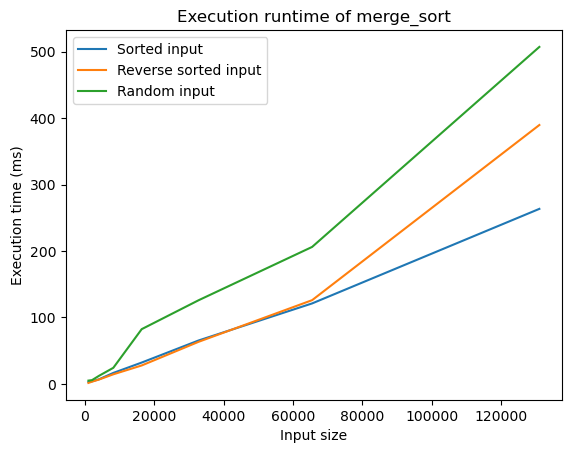

In [63]:
runtime_test_sort(merge_sort, [2**i for i in range(10, 18)])

### Quick sort

**Implement the reorder step in the following function.**

Reordering must be done in place: the result must be in the input, you must not allocate a new array, the function returns the new position of the pivot element.

The unit test must says that your function seems correct.

In [6]:
def reorder_array(array, start=None, stop=None):
    # -reorder the element in the sub-array array[start:stop]
    # -the pivot is the last element of the sub-array
    # -reorder the sub-array such that all the elements smaller than the pivot are before the pivot and conversly
    # -return the position of the pivot at the end of the function

    if start is None:
        start = 0
    if stop is None:
        stop = len(array)

    ########################
    #
    # Your code here !
    #
    ########################
    pass

test_reorder_array(reorder_array);

--- Running test: 
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work: the pivot index is incorrect
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work, some elements before the pivot are greater than the pivot.
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work, some elements after the pivot are smaller than the pivot.
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work: the pivot index is incorrect
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work, some elements before the pivot are greater than the pivot.
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work, some elements after the pivot are smaller than the pivot.
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work: the pivot index is incorrect
✗  Result of 'reorder_array()' is incorrect.
Reorder array does not work, some elements before the pivot are greater than the pivot.
✗  Result

**Implement quick sort in the following function.**

The sorting must be done in place: the result must be in the input, you must not allocate a new array, the function returns nothing.

The unit test must says that your function seems correct.

In [7]:
def quick_sort(array, start=None, stop=None):
    # sort the given sub-array array[start:stop] with quick-sort algorithm

    if start is None:
        start = 0
    if stop is None:
        stop = len(array)

    ########################
    #
    # Your code here !
    #
    ########################
    pass

unit_test_sort(quick_sort, inplace=True);

--- Running test: 
✗  quick_sort([0.55 0.72 0.6  0.54 0.42 0.65 0.44 0.89 0.96 0.38]) -> [0.55 0.72 0.6  0.54 0.42 0.65 0.44 0.89 0.96 0.38] (expected: [0.38 0.42 0.44 0.54 0.55 0.6  0.65 0.72 0.89 0.96])
✗  quick_sort([0.58 0.93 0.77 0.07 0.62 0.13 0.6  0.79 0.45 0.6 ]) -> [0.58 0.93 0.77 0.07 0.62 0.13 0.6  0.79 0.45 0.6 ] (expected: [0.07 0.13 0.45 0.58 0.6  0.6  0.62 0.77 0.79 0.93])
✗  quick_sort([0.36 0.37 0.68 0.29 0.62 0.57 0.5  0.53 0.5  0.82]) -> [0.36 0.37 0.68 0.29 0.62 0.57 0.5  0.53 0.5  0.82] (expected: [0.29 0.36 0.37 0.5  0.5  0.53 0.57 0.62 0.68 0.82])
✗  quick_sort([0.87 0.09 0.39 0.08 0.33 0.79 0.18 0.22 0.22 0.12]) -> [0.87 0.09 0.39 0.08 0.33 0.79 0.18 0.22 0.22 0.12] (expected: [0.08 0.09 0.12 0.18 0.22 0.22 0.33 0.39 0.79 0.87])
✗  quick_sort([0.94 0.89 0.45 0.92 0.99 0.09 0.8  0.8  0.49 0.29]) -> [0.94 0.89 0.45 0.92 0.99 0.09 0.8  0.8  0.49 0.29] (expected: [0.09 0.29 0.45 0.49 0.8  0.8  0.89 0.92 0.94 0.99])
✗ 0/5 tests passed.
--- Test finished.


Now let's verify that the runtime of the implemented algorithm matches the expected runtime complexity.

We are going to run the implemented algorithm on three kind of inputs of various sizes:

- already sorted arrays
- reverse sorted arrays
- random arrays

**What is the best and worst case time complexity of the algorithm?**

**Does the execution runtime of the implementation matches with those theoretical runtime complexities?**

--- Running runtime test for 'quick_sort':
	 - Input is a sorted array:
		array size: 256 -> time 0.001 s
		array size: 512 -> time 0.000 s
		array size: 768 -> time 0.000 s
		array size: 1,024 -> time 0.000 s
		array size: 1,280 -> time 0.000 s
		array size: 1,536 -> time 0.005 s
		array size: 1,792 -> time 0.001 s
		array size: 2,048 -> time 0.001 s
	 - Input is a reverse sorted array:
		array size: 256 -> time 0.001 s
		array size: 512 -> time 0.001 s
		array size: 768 -> time 0.000 s
		array size: 1,024 -> time 0.000 s
		array size: 1,280 -> time 0.000 s
		array size: 1,536 -> time 0.001 s
		array size: 1,792 -> time 0.000 s
		array size: 2,048 -> time 0.001 s
	 - Input is a random array:
		array size: 256 -> time 0.000 s
		array size: 512 -> time 0.001 s
		array size: 768 -> time 0.001 s
		array size: 1,024 -> time 0.000 s
		array size: 1,280 -> time 0.000 s
		array size: 1,536 -> time 0.001 s
		array size: 1,792 -> time 0.001 s
		array size: 2,048 -> time 0.000 s


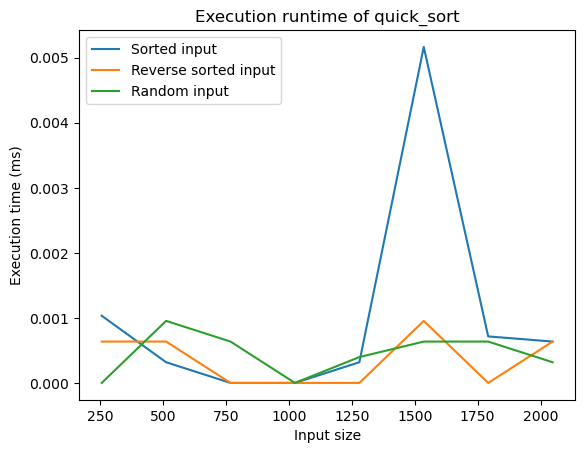

In [8]:
runtime_test_sort(quick_sort, [256*i for i in range(1, 9)])

### Matrix multiplication

**Implement the naive matrix multiplication algorithm.**

The unit test must says that your function seems correct.

In [9]:
def naive_matrix_mulplication(A, B):
    """
    O(n^3) naive square matrix mutiplication
    """
    import numpy as np
    res = np.zeros_like(A)

    ########################
    #
    # Your code here !    
    #
    ########################
    return res

unit_test_square_matrix_multiplication(naive_matrix_mulplication);

--- Running test: 
✗  naive_matrix_mulplication([[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]
 [8 8 1 6]], [[7 7 8 1]
 [5 9 8 9]
 [4 3 0 3]
 [5 0 2 3]]) -> [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] (expected: [[ 62  44  46  23]
 [131 139 138 112]
 [ 92  71  60  77]
 [130 131 140 101]])
✗  naive_matrix_mulplication([[8 1 3 3]
 [3 7 0 1]
 [9 9 0 4]
 [7 3 2 7]], [[2 0 0 4]
 [5 5 6 8]
 [4 1 4 9]
 [8 1 1 7]]) -> [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] (expected: [[ 57  11  21  88]
 [ 49  36  43  75]
 [ 95  49  58 136]
 [ 93  24  33 119]])
✗  naive_matrix_mulplication([[9 9 3 6]
 [7 2 0 3]
 [5 9 4 4]
 [6 4 4 3]], [[4 4 8 4]
 [3 7 5 5]
 [0 1 5 9]
 [3 0 5 0]]) -> [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] (expected: [[ 81 102 162 108]
 [ 43  42  81  38]
 [ 59  87 125 101]
 [ 45  56 103  80]])
✗  naive_matrix_mulplication([[0.62 0.67 0.97 ... 0.22 0.57 0.45]
 [0.97 0.68 0.09 ... 0.26 0.59 0.48]
 [0.49 0.46 0.52 ... 0.7  0.9  0.12]
 ...
 [0.11 0.73 0.62 ... 0.17 0.96 0.7 ]
 [0.7  0.59 0.21 ... 0.22

**Implement the Strassen matrix multiplication algorithm.**

The unit test must says that your function seems correct.

In [10]:
def strassen_matrix_mulplication(A, B):
  """
  Strassen's square matrix mutiplication
  Assume that the size of A and B is n*n with n=2^k
  """
  import numpy as np
  res = np.zeros_like(A)

  ########################
  #
  # Your code here !    
  #
  ########################

  return res

unit_test_square_matrix_multiplication(strassen_matrix_mulplication);

--- Running test: 
✗  strassen_matrix_mulplication([[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]
 [8 8 1 6]], [[7 7 8 1]
 [5 9 8 9]
 [4 3 0 3]
 [5 0 2 3]]) -> [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] (expected: [[ 62  44  46  23]
 [131 139 138 112]
 [ 92  71  60  77]
 [130 131 140 101]])
✗  strassen_matrix_mulplication([[8 1 3 3]
 [3 7 0 1]
 [9 9 0 4]
 [7 3 2 7]], [[2 0 0 4]
 [5 5 6 8]
 [4 1 4 9]
 [8 1 1 7]]) -> [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] (expected: [[ 57  11  21  88]
 [ 49  36  43  75]
 [ 95  49  58 136]
 [ 93  24  33 119]])
✗  strassen_matrix_mulplication([[9 9 3 6]
 [7 2 0 3]
 [5 9 4 4]
 [6 4 4 3]], [[4 4 8 4]
 [3 7 5 5]
 [0 1 5 9]
 [3 0 5 0]]) -> [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]] (expected: [[ 81 102 162 108]
 [ 43  42  81  38]
 [ 59  87 125 101]
 [ 45  56 103  80]])
✗  strassen_matrix_mulplication([[0.62 0.67 0.97 ... 0.22 0.57 0.45]
 [0.97 0.68 0.09 ... 0.26 0.59 0.48]
 [0.49 0.46 0.52 ... 0.7  0.9  0.12]
 ...
 [0.11 0.73 0.62 ... 0.17 0.96 0.7 ]
 [0.7  0.59 0